## Step 1: Import Packages

In [50]:
import os
import sklearn
import pandas as pd
import numpy as np
import openpyxl as xl

## Step 2: Setup Working Directory

In [51]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-446/Topic 8 - Random Forests Classification')

In [52]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-446/Topic 8 - Random Forests Classification'

## Step 3: Import and Clean Data

In [53]:
TrainTestData = pd.read_excel("GrainStorageBins1.xlsx", sheet_name="TrainTestData")

#Clean column names
TrainTestData.columns = (
    TrainTestData.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)
print("Column names:", TrainTestData.columns.tolist())
print(TrainTestData.head())

Column names: ['record', 'product', 'dryer', 'warranty', 'stdbushels', 'purchased']
   record  product dryer   warranty  stdbushels  purchased
0       1    Elite    No   Extended       36204          1
1       2    Elite    No  InService       22001          0
2       3  Premium    No   Extended       10583          0
3       4  Premium    No   Extended       40217          0
4       5  Premium    No   Extended       15910          0


## Step 4: Define features

In [54]:
feature_columns = [
    'product',
    'dryer',
    'warranty',
    'stdbushels'
]

print("Feature Columns:", feature_columns)

Feature Columns: ['product', 'dryer', 'warranty', 'stdbushels']


## Step 5: Convert String to Numeric

In [55]:
from sklearn.preprocessing import LabelEncoder

#Create a copy of the original dataset
TrainTestData_encoded = TrainTestData.copy()

#Initialize one encoder per column
label_encoders = {}

#Encode specific columns
categorical_columns = ['product', 'dryer', 'warranty']

for column in categorical_columns:
    le = LabelEncoder()
    TrainTestData_encoded[column] = le.fit_transform(TrainTestData_encoded[column].astype(str))
    label_encoders[column] = le

#Encode purchase column even if it is text dtype
if TrainTestData_encoded['purchased'].dtype == 'object':
    le_target = LabelEncoder()
    TrainTestData_encoded['purchased'] = le_target.fit_transform(TrainTestData_encoded['purchased'].astype(str))

#Define X and Y from the encoded dataframe
X = TrainTestData_encoded[feature_columns]
Y = TrainTestData_encoded['purchased']

#Confirm everything is numeric
print(X.dtypes)
print(Y.dtype)

product       int64
dryer         int64
warranty      int64
stdbushels    int64
dtype: object
int64


## Step 6: Define Feature Matrix

In [56]:
X = TrainTestData_encoded[feature_columns]
Y = TrainTestData_encoded['purchased']

print("X preview:")
print(X.head())

print("\nY preview:")
print(Y.head())

print("\nX data types:")
print(X.dtypes)

print("\nY data type:")
print(Y.dtype)

X preview:
   product  dryer  warranty  stdbushels
0        1      0         0       36204
1        1      0         1       22001
2        3      0         0       10583
3        3      0         0       40217
4        3      0         0       15910

Y preview:
0    1
1    0
2    0
3    0
4    0
Name: purchased, dtype: int64

X data types:
product       int64
dryer         int64
warranty      int64
stdbushels    int64
dtype: object

Y data type:
int64


## Step 7: Split Data into Training and Testing Sets (80/20 Split)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

## Step 8: Create Random Forest Classifier

In [58]:
from sklearn.ensemble import RandomForestClassifier

rfclf = RandomForestClassifier(
    bootstrap=True,
    class_weight=None,
    criterion='entropy',
    max_depth=8,
    max_leaf_nodes=3,
    max_samples=200,
    min_impurity_decrease=0.0,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    n_estimators=500,
    n_jobs=1,
    oob_score=False,
    random_state=38,
    verbose=0,
    warm_start=False
)

print(rfclf)

RandomForestClassifier(criterion='entropy', max_depth=8, max_leaf_nodes=3,
                       max_samples=200, n_estimators=500, n_jobs=1,
                       random_state=38)


## Step 9: Train the Model

In [59]:
rfclf.fit(X_train, Y_train)
print("Model training complete.")

Model training complete.


## Step 10: Obtain the Most Important Feature

In [60]:
feature_scores = pd.Series(
    rfclf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Most Important Features")
print(feature_scores)

Most Important Features
warranty      0.466336
product       0.352448
dryer         0.103932
stdbushels    0.077284
dtype: float64


## Step 11: Predict Responses

In [61]:
#Use the trained model to make predictions on the test data
Y_pred = rfclf.predict(X_test)

#Preview predictions
print("Predicted values:")
print(Y_pred[:10])

print("\nActual values:")
print(Y_test.values[:10])

Predicted values:
[0 0 0 0 1 0 1 0 0 0]

Actual values:
[0 0 0 0 1 0 1 0 0 0]


## Step 12: Evaluate the Model

In [62]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(Y_test, Y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       164
           1       0.98      0.75      0.85        76

    accuracy                           0.92       240
   macro avg       0.94      0.87      0.90       240
weighted avg       0.92      0.92      0.91       240



## Step 13: Create Confusion Matrix

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[163   1]
 [ 19  57]]


## Step 14: Visualization

LABELS INFO:

 prob_min         : Minimum probability in a particular decile
 prob_max         : Minimum probability in a particular decile
 prob_avg         : Average probability in a particular decile
 cnt_events       : Count of events in a particular decile
 cnt_resp         : Count of responders in a particular decile
 cnt_non_resp     : Count of non-responders in a particular decile
 cnt_resp_rndm    : Count of responders if events assigned randomly in a particular decile
 cnt_resp_wiz     : Count of best possible responders in a particular decile
 resp_rate        : Response Rate in a particular decile [(cnt_resp/cnt_cust)*100]
 cum_events       : Cumulative sum of events decile-wise 
 cum_resp         : Cumulative sum of responders decile-wise 
 cum_resp_wiz     : Cumulative sum of best possible responders decile-wise 
 cum_non_resp     : Cumulative sum of non-responders decile-wise 
 cum_events_pct   : Cumulative sum of percentages of events decile-wise 
 cum_resp_pct     : Cu

,decile,prob_min,prob_max,prob_avg,cnt_cust,cnt_resp,cnt_non_resp,cnt_resp_rndm,cnt_resp_wiz,resp_rate,cum_cust,cum_resp,cum_resp_wiz,cum_non_resp,cum_cust_pct,cum_resp_pct,cum_resp_pct_wiz,cum_non_resp_pct,KS,lift
0,1,0.570,0.717,0.668,24.0,23.0,1.0,7.6,24,95.833,24.0,23.0,24,1.0,10.0,30.263,31.579,0.610,29.653,3.026
1,2,0.533,0.563,0.547,24.0,24.0,0.0,7.6,24,100.000,48.0,47.0,48,1.0,20.0,61.842,63.158,0.610,61.232,3.092
2,3,0.403,0.532,0.468,24.0,17.0,7.0,7.6,24,70.833,72.0,64.0,72,8.0,30.0,84.211,94.737,4.878,79.333,2.807
3,4,0.382,0.403,0.394,24.0,4.0,20.0,7.6,4,16.667,96.0,68.0,76,28.0,40.0,89.474,100.000,17.073,72.401,2.237
4,5,0.340,0.381,0.365,24.0,3.0,21.0,7.6,0,12.500,120.0,71.0,76,49.0,50.0,93.421,100.000,29.878,63.543,1.868
5,6,0.332,0.340,0.337,24.0,2.0,22.0,7.6,0,8.333,144.0,73.0,76,71.0,60.0,96.053,100.000,43.293,52.760,1.601
6,7,0.132,0.331,0.173,24.0,2.0,22.0,7.6,0,8.333,168.0,75.0,76,93.0,70.0,98.684,100.000,56.707,41.977,1.410
7,8,0.106,0.131,0.118,24.0,1.0,23.0,7.6,0,4.167,192.0,76.0,76,116.0,80.0,100.000,100.000,70.732,29.268,1.250
8,9,0.043,0.067,0.051,24.0,0.0,24.0,7.6,0,0.000,216.0,76.0,76,140.0,90.0,100.000,100.000,85.366,14.634,1.111
9,10,0.041,0.043,0.043,24.0,0.0,24.0,7.6,0,0.000,240.0,76.0,76,164.0,100.0,100.000,100.000,100.000,0.000,1.000


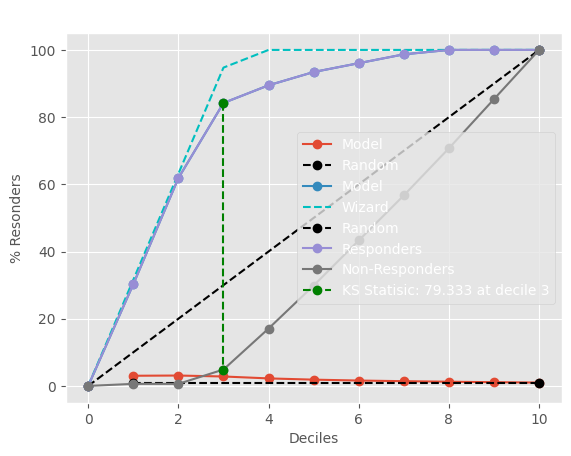

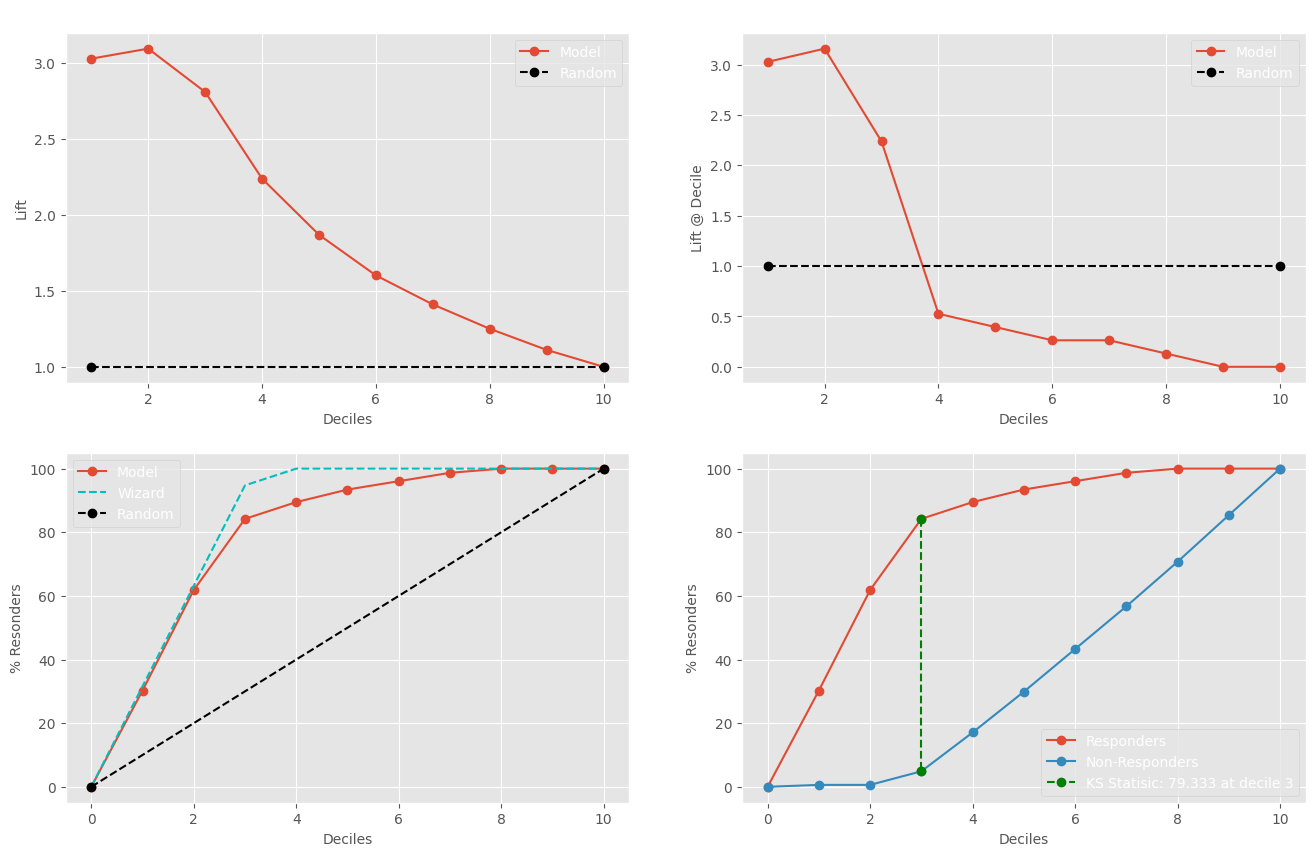

In [64]:
import kds

#Get predicted probabilities for the test data
#[:, 1] = probability of class 1 ("purchased")
Y_prob = rfclf.predict_proba(X_test)[:, 1]

#Lift Plot
kds.metrics.plot_lift(Y_test, Y_prob)

#Cumulative Gain Plot
kds.metrics.plot_cumulative_gain(Y_test, Y_prob)

#KS Statistic Plot
kds.metrics.plot_ks_statistic(Y_test, Y_prob)

#Decile Table
decile_table = kds.metrics.decile_table(Y_test, Y_prob)
print(decile_table)

kds.metrics.report(Y_test, Y_prob, plot_style='ggplot')

## Step 15: Calculate Comprehensive Model Metrics

In [65]:
from sklearn import metrics

# Calculate model performance metrics
accuracy = metrics.accuracy_score(Y_test, Y_pred)
f1_score_macro = metrics.f1_score(Y_test, Y_pred, average='macro')
f1_score_micro = metrics.f1_score(Y_test, Y_pred, average='micro')
precision_score = metrics.precision_score(Y_test, Y_pred)
recall_score = metrics.recall_score(Y_test, Y_pred)
hamming_loss = metrics.hamming_loss(Y_test, Y_pred)
jaccard_score = metrics.jaccard_score(Y_test, Y_pred)
logloss = metrics.log_loss(Y_test, Y_prob)
zero_one_loss = metrics.zero_one_loss(Y_test, Y_pred)
roc_auc_score = metrics.roc_auc_score(Y_test, Y_prob)
matthews_corrcoef = metrics.matthews_corrcoef(Y_test, Y_pred)

# Print all metrics clearly
print("Comprehensive Model Metrics")
print("----------------------------")
print("accuracy:", accuracy)
print("f1_score_macro:", f1_score_macro)
print("f1_score_micro:", f1_score_micro)
print("precision_score:", precision_score)
print("recall_score:", recall_score)
print("hamming_loss:", hamming_loss)
print("jaccard_score:", jaccard_score)
print("logloss:", logloss)
print("zero_one_loss:", zero_one_loss)
print("roc_auc_score:", roc_auc_score)
print("matthews_corrcoef:", matthews_corrcoef)

Comprehensive Model Metrics
----------------------------
accuracy: 0.9166666666666666
f1_score_macro: 0.8964714002243119
f1_score_micro: 0.9166666666666666
precision_score: 0.9827586206896551
recall_score: 0.75
hamming_loss: 0.08333333333333333
jaccard_score: 0.7402597402597403
logloss: 0.391835535781915
zero_one_loss: 0.08333333333333337
roc_auc_score: 0.9494945442875481
matthews_corrcoef: 0.8083417533258842


## Step 16: Test Max Sample Parameter

In [66]:
#Test max_samples from 250 to 800 in increments of 50
sample_values = range(250, 801, 50)

results = []

for sample_size in sample_values:
    rfclf_test = RandomForestClassifier(
        bootstrap=True,
        class_weight=None,
        criterion='entropy',
        max_depth=8,
        max_leaf_nodes=3,
        max_samples=sample_size,
        min_impurity_decrease=0.0,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=2,
        min_weight_fraction_leaf=0.0,
        n_estimators=500,
        n_jobs=1,
        oob_score=False,
        random_state=38,
        verbose=0,
        warm_start=False
    )

    #Train the model
    rfclf_test.fit(X_train, Y_train)

    #Predict test data
    Y_pred_test = rfclf_test.predict(X_test)

    #Calculate metrics
    accuracy = metrics.accuracy_score(Y_test, Y_pred_test)
    precision = metrics.precision_score(Y_test, Y_pred_test)

    #Store results
    results.append({
        'max_samples': sample_size,
        'accuracy': accuracy,
        'precision': precision
    })

#Convert results to DataFrame
results_df = pd.DataFrame(results)

print("Random Forest max_samples Tuning Results")
print(results_df)

Random Forest max_samples Tuning Results
    max_samples  accuracy  precision
0           250  0.920833   0.983051
1           300  0.920833   0.983051
2           350  0.920833   0.983051
3           400  0.920833   0.983051
4           450  0.925000   0.983333
5           500  0.925000   0.983333
6           550  0.925000   0.983333
7           600  0.925000   0.983333
8           650  0.925000   0.983333
9           700  0.920833   0.983051
10          750  0.920833   0.983051
11          800  0.920833   0.983051


In [67]:
#Sort by accuracy and precision to get best results
best_results = results_df.sort_values(
    by=['accuracy', 'precision'],
    ascending=False
)

print("Best Performing max_samples Values")
print(best_results)

best_max_samples = best_results.iloc[0]['max_samples']
best_accuracy = best_results.iloc[0]['accuracy']
best_precision = best_results.iloc[0]['precision']

print("Optimal max_samples:", best_max_samples)
print("Best accuracy:", best_accuracy)
print("Best precision:", best_precision)

Best Performing max_samples Values
    max_samples  accuracy  precision
4           450  0.925000   0.983333
5           500  0.925000   0.983333
6           550  0.925000   0.983333
7           600  0.925000   0.983333
8           650  0.925000   0.983333
0           250  0.920833   0.983051
1           300  0.920833   0.983051
2           350  0.920833   0.983051
3           400  0.920833   0.983051
9           700  0.920833   0.983051
10          750  0.920833   0.983051
11          800  0.920833   0.983051
Optimal max_samples: 450.0
Best accuracy: 0.925
Best precision: 0.9833333333333333


## Step 17: Conclusion

This analysis used a Random Forest model to predict whether a customer would purchase a grain storage bin. The model was built using 500 decision trees, a maximum depth of 8, and entropy to guide how decisions are made. One important setting, called max_samples, was tested at different levels, and the best value was found to be 450. This setting gave the best results, with an accuracy of 92.5% and a precision of 98.33%, showing that adjusting how much data each tree uses can improve performance up to a certain point.

The results also showed that some factors mattered more than others, especially the type of product and the warranty. This means customers are strongly influenced by what kind of storage bin they are buying and the protection that comes with it. Overall, the model performed very well. It correctly predicted outcomes over 91% of the time, and when it predicted a purchase, it was almost always correct. However, the recall was lower at 75%, meaning the model missed some actual buyers. This indicates the model is cautious since it avoids incorrectly predicting purchases but may overlook some real opportunities.

The confusion matrix supports this, showing few false positives but more false negatives. In business terms, this means the model is good at avoiding targeting non-buyers but might miss some potential customers. Other metrics, like the ROC AUC score (0.949) and Matthews correlation coefficient (0.808), confirm that the model is strong and reliable. The lift and cumulative gains results also show that the model performs much better than random guessing, especially in identifying the most likely buyers early on.

Overall, this Random Forest model is effective for predicting customer purchases and can be useful for marketing decisions. The final model, with max_samples set to 450, provides a strong balance between accuracy and precision and can help improve targeting and campaign success.